In [2]:
import numpy as np
from sklearn.datasets import make_classification

In [6]:
x , y = make_classification(n_samples= 100  ,n_features=2, n_classes=2 ,hypercube= False,class_sep=20,
                            n_redundant=0 , n_informative=1, n_clusters_per_class=1,random_state=41)

In [4]:
import matplotlib.pyplot as plt

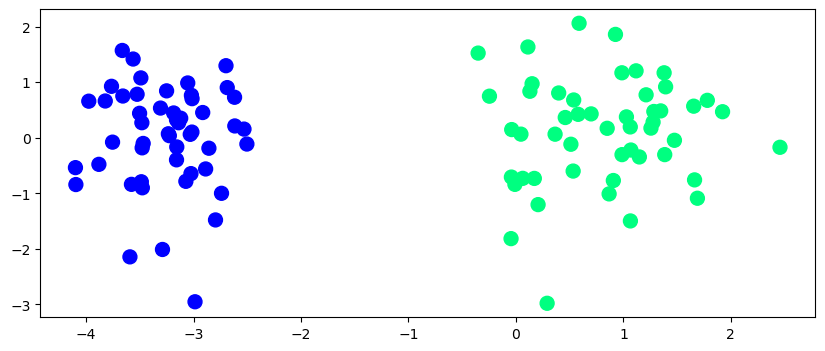

In [7]:
plt.figure(figsize=(10,4))
plt.scatter(x[:,0],x[:,1],c=y , cmap='winter' , s=100)

In [13]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty= None ,solver='sag' )


In [14]:
lor.fit(x,y)

c:\Users\zhass\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [16]:
print(lor.coef_)
print(lor.intercept_)

[[4.87872726 0.22786324]]
[5.84329307]


In [17]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 =-(lor.intercept_/lor.coef_[0][1])

In [20]:
X_input = np.linspace(-3,3,100)
Y_input = m1 * X_input + b1

In [65]:
def gd(x,y):
    x = np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.5
    for i in range(6000):
        y_hat = sigmoid(np.dot(x , weights))
        weights = weights + lr * (np.dot((y - y_hat),x )/ x.shape[0])

    return weights[1:,] ,  weights[0]

In [64]:
def sigmoid (z):
    return 1/(1 + np.exp(-z))

In [66]:
coef_ , intercept_ = gd(x,y)

In [67]:
coef_

array([4.96709762, 0.22313229])

In [68]:
intercept_

np.float64(6.016113450269771)

In [69]:
m = - (coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [70]:
x_input = np.linspace(-3,3,100)
y_input = m * x_input + b

(-3.0, 2.0)

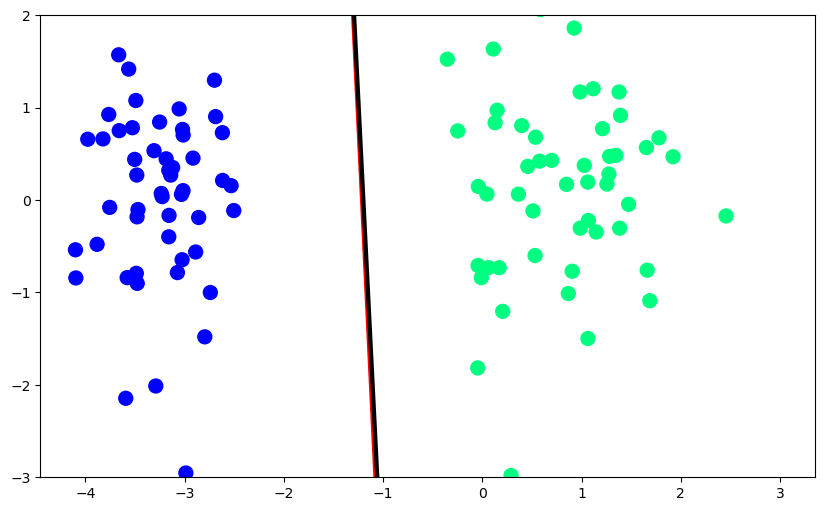

: 

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color = 'red' , linewidth = 3)
plt.plot(X_input,Y_input,color = 'black' , linewidth = 3)
plt.scatter(x[:,0],x[:,1],c=y , cmap='winter' , s= 100)
plt.ylim(-3,2)